This tutorial demonstrates that the distribution of relaxation times (DRT) can also be deconvolved using other norms to analyze real impedance data. More details can be found in the article entitled 'Beyond Ridge Regression: Enhancing Distribution of Relaxation Times Deconvolution' (DOI: 10.1149/1945-7111/ad576a).

In [1]:
# importing various package
import numpy as np
from math import log10, pi, sin, cos, log
from numpy.linalg import norm
from scipy.linalg import null_space
import matplotlib.pyplot as plt
import time
import compute_DRT
import importlib
from cvxopt import matrix, solvers
from scipy.optimize import minimize
import pandas as pd
import scipy.io
from numpy import diff
from bayes_opt import BayesianOptimization
import cvxpy as cp

In [2]:
# options for the plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=15)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

# 1. Prepare DRT Deconvolution for experimental Data from $(\text{Ba}_{0.95}\text{La}_{0.05})_{1-0.05}\text{FeO}_{3-\delta}$ as an intermediate-temperature solid Oxide Fuel Cell Cathode at 500C (DOI: 10.1016/j.ijhydene.2021.10.098)

## 1.1 Load the Data

In [3]:
df=pd.read_csv('./BLF_D5_pO2_60%_T500.csv')
N_freqs = df.shape[0]
freq_vec = np.flip(df['freq'].values)
Z_exp = np.flip(df['Real'].values - 1j*df['Imag'].values)
Z_exp_re = Z_exp.real
Z_exp_im = Z_exp.imag

## 1.2 Define the Range of log Timescales

In [4]:
# define the range of log timescales with tau=1/f as in the previous papers
N_tau = 71
log_tau_min = -5
log_tau_max = 2
tau_vec = np.logspace(log_tau_min, log_tau_max, num = N_tau, endpoint=True)
log_tau_vec = np.log(tau_vec)

## 1.3 Define an equivalent Circuit Model (ECM)

In [5]:
mat500 = scipy.io.loadmat('BLF_D5_pO2_60%_T_500.mat')
data = mat500['param_value']
Rinf = data[0][0]
R1 = data[1][0]
R2 = data[2][0]
tau1 = data[3][0]
tau2 = data[4][0]
phi1 = data[5][0]
phi2 = data[6][0]
L0 = data[7][0]       

Z_ECM = Rinf + 1j*2.*pi*freq_vec*L0 + R1/(1+(1j*2.*pi*freq_vec*tau1)**phi1) + R2/(1+(1j*2.*pi*freq_vec*tau2)**phi2)
gamma_ECM_1 = (R1)/(2.*pi)*sin((1.-phi1)*pi)/(np.cosh(phi1*np.log(tau_vec/tau1))-cos((1.-phi1)*pi))
gamma_ECM_2 = (R2)/(2.*pi)*sin((1.-phi2)*pi)/(np.cosh(phi2*np.log(tau_vec/tau2))-cos((1.-phi2)*pi))
gamma_ECM = (gamma_ECM_1 +gamma_ECM_2).reshape(N_tau)

## 1.4 Plot the Nyquist Plot of the experimental Impedance

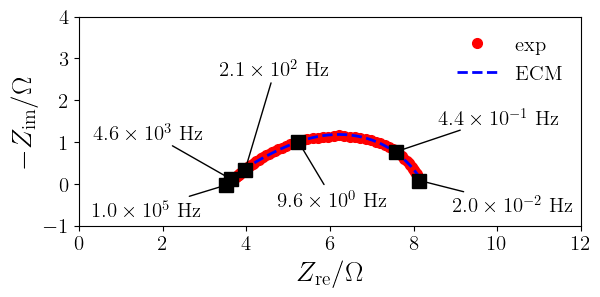

In [6]:
fig, ax = plt.subplots()
plt.plot(np.real(Z_exp), -np.imag(Z_exp), 'o', markersize=7, color='red', label='exp')
plt.plot(np.real(Z_ECM), -np.imag(Z_ECM), '--', linewidth=2, color='blue', label='ECM')
plt.plot(np.real(Z_exp[0]), -np.imag(Z_exp[0]), 's', markersize=10, color='black')
plt.plot(np.real(Z_exp[20]), -np.imag(Z_exp[20]), 's', markersize=10, color='black')
plt.plot(np.real(Z_exp[40]), -np.imag(Z_exp[40]), 's', markersize=10, color='black')
plt.plot(np.real(Z_exp[60]), -np.imag(Z_exp[60]), 's', markersize=10, color='black')
plt.plot(np.real(Z_exp[80]), -np.imag(Z_exp[80]), 's', markersize=10, color='black')
plt.plot(np.real(Z_exp[100]), -np.imag(Z_exp[100]), 's', markersize=10, color='black')
plt.annotate(r'$2.0 \times 10^{-2}$ Hz', xy=(np.real(Z_exp[0]), -np.imag(Z_exp[0])), xytext=(np.real(Z_exp[0])+0.8, -0.7-np.imag(Z_exp[0])),
             arrowprops=dict(arrowstyle="-", connectionstyle="arc"))
plt.annotate(r'$4.4 \times 10^{-1}$ Hz', xy=(np.real(Z_exp[20]), -np.imag(Z_exp[20])), xytext=(np.real(Z_exp[20])+1, 0.7-np.imag(Z_exp[20])),
             arrowprops=dict(arrowstyle="-", connectionstyle="arc"))
plt.annotate(r'$9.6 \times 10^{0}$ Hz', xy=(np.real(Z_exp[40]), -np.imag(Z_exp[40])), xytext=(np.real(Z_exp[40])-0.5, -1.5-np.imag(Z_exp[40])),
             arrowprops=dict(arrowstyle="-", connectionstyle="arc"))
plt.annotate(r'$2.1 \times 10^{2}$ Hz', xy=(np.real(Z_exp[60]), -np.imag(Z_exp[60])), xytext=(np.real(Z_exp[60])-0.6, 2.3-np.imag(Z_exp[60])),
             arrowprops=dict(arrowstyle="-", connectionstyle="arc"))
plt.annotate(r'$4.6 \times 10^{3}$ Hz', xy=(np.real(Z_exp[80]), -np.imag(Z_exp[80])), xytext=(np.real(Z_exp[80])-3.3, 1-np.imag(Z_exp[80])),
             arrowprops=dict(arrowstyle="-", connectionstyle="arc"))
plt.annotate(r'$1.0 \times 10^{5}$ Hz', xy=(np.real(Z_exp[100]), -np.imag(Z_exp[100])), xytext=(np.real(Z_exp[100])-3.2, -0.7-np.imag(Z_exp[100])),
             arrowprops=dict(arrowstyle="-", connectionstyle="arc"))
plt.legend(frameon=False, fontsize = 15, loc='upper right')
plt.axis('scaled')
plt.xticks(np.arange(0, 12.01, 2))
plt.yticks(np.arange(-1, 4.01, 1))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(r'$Z_{\rm re}/\Omega$', fontsize = 20)
plt.ylabel(r'$-Z_{\rm im}/\Omega$', fontsize = 20)
fig.set_size_inches(6.472, 4)
plt.show()

# 2. Compute the DRT through Ridge Regression (RR)

## 2.1 Compute the Matrices for quadratic Programming with $\lambda=10^{-3}$

In [7]:
importlib.reload(compute_DRT)

lambda_0 = 1E-3

# data
Z_re = Z_exp.real
Z_im = Z_exp.imag
Z_RR = np.zeros(2*N_freqs)
Z_RR[:N_freqs] = Z_exp.real.flatten()
Z_RR[N_freqs:] = Z_exp.imag.flatten()

# compute matrix A
A_complex = compute_DRT.compute_A_complex(freq_vec, log_tau_vec)
A_re = np.real(A_complex)
A_im = np.imag(A_complex)

A_R0 = np.zeros((2*N_freqs,1))
A_R0[0:N_freqs,0] = 1.0
A = np.hstack( ( A_R0, np.vstack((A_re, A_im)) ) )

# compute matrix L
L2_standard = compute_DRT.compute_L2(log_tau_vec)
L2 = np.hstack( ( np.zeros((N_tau-2, 1)), L2_standard ) )

# solve 1/2 x.T@(Q@x) + p@x
Q = A.T@A + lambda_0*L2.T@L2 
p = -A.T@Z_RR

# G@x<=0
G = -np.identity(N_tau+1)
h = np.zeros(N_tau+1)

# Define and solve the CVXopt
# to be defined below: 
Q_cvxopt = matrix(Q)
p_cvxopt = matrix(p)
G_cvxopt = matrix(G)
h_cvxopt = matrix(h)

## 2.2 Deconvolve the DRT

In [8]:
sol = solvers.qp(Q_cvxopt, p_cvxopt, G_cvxopt, h_cvxopt)
x = np.array(sol['x']).flatten()
gamma_hat = x[1:]

     pcost       dcost       gap    pres   dres
 0: -1.5671e+03 -1.6492e+03  4e+02  9e+00  5e-02
 1: -1.5595e+03 -1.6085e+03  5e+01  2e-15  9e-17
 2: -1.5665e+03 -1.5726e+03  6e+00  9e-16  7e-17
 3: -1.5675e+03 -1.5683e+03  8e-01  8e-16  9e-17
 4: -1.5677e+03 -1.5678e+03  1e-01  8e-16  9e-17
 5: -1.5677e+03 -1.5677e+03  1e-02  7e-16  8e-17
 6: -1.5677e+03 -1.5677e+03  2e-03  8e-16  8e-17
 7: -1.5677e+03 -1.5677e+03  2e-04  1e-15  8e-17
Optimal solution found.


## 2.3 Compare the DRT obtained with RR against the ECM-based DRT

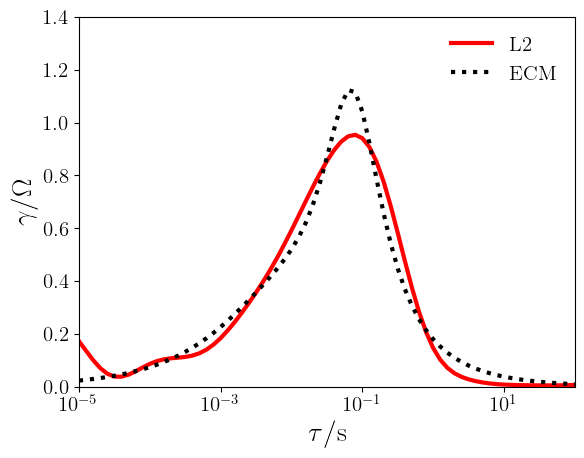

In [9]:
plt.semilogx(tau_vec, gamma_hat, '-', linewidth=3, color='red', label='L2')
plt.semilogx(tau_vec, gamma_ECM, ':', linewidth=3, color='black', label='ECM')
plt.xlabel('$\\tau/\\rm s$', fontsize = 20)
plt.ylabel('$\\gamma/\\Omega$', fontsize = 20)
plt.legend(frameon=False, fontsize=15, loc='upper right')
plt.xlim(np.min(tau_vec), np.max(tau_vec))
plt.ylim([0, 1.4])
plt.yticks(np.arange(0, 1.41, step=0.2))
fig.set_size_inches(6.472, 4)
plt.show()

# 3. DRT Deconvolution with different Norms

To implement these optimization problems in Python using linear programming, we can use libraries like `cvxpy`, which is designed for convex optimization. Linear programming typically involves linear objective functions and constraints, but we can handle the  $\ell_1$ and $\ell_\infty$ norms by introducing auxiliary variables and additional constraints.

Let's outline the implementation for each problem:

### Minimizing $\ell_\infty$ norm of $Ax - b$ with $\ell_1$ regularization of $Lx$

This problem can be formulated as:
$$
\begin{align*}
\min_{x, t} \ & t + \lambda \|Lx\|_1 \\
\text{s.t.} \ & -t \mathbf{1} \leq Ax - b \leq t \mathbf{1}
\end{align*}
$$
where $t$ is an auxiliary variable representing the $\ell_\infty$ norm of $Ax - b$, and $\mathbf{1}$ is a vector of ones.

### Minimizing $\ell_\infty$ norm of $Ax - b$ with $\ell_\infty$ regularization of $Lx$

This problem can be formulated as:
$$
\begin{align*}
\min_{x, t, u} \ & t + \lambda u \\
\text{s.t.} \ & -t \mathbf{1} \leq Ax - b \leq t \mathbf{1} \\
              & -u \mathbf{1} \leq Lx \leq u \mathbf{1}
\end{align*}
$$
where $u$ is an auxiliary variable representing the $\ell_\infty$ norm of $Lx$.

### Minimizing $\ell_1$ norm of $Ax - b$ with $\ell_\infty$ regularization of $Lx$

This problem can be formulated as:
$$
\begin{align*}
\min_{x, u} \ & \|Ax - b\|_1 + \lambda u \\
\text{s.t.} \ & -u \mathbf{1} \leq Lx \leq u \mathbf{1}
\end{align*}
$$

### Minimizing $\ell_1$ norm of $Ax - b$ with $\ell_1$ regularization of $Lx$

This problem can be formulated as:
$$
\min_x \ \|Ax - b\|_1 + \lambda \|Lx\|_1
$$

## 3.1 Define the required Matrices and Vectors

In [10]:
importlib.reload(compute_DRT)

L1 = compute_DRT.compute_L1(log_tau_vec) # first-order differentiation matrix
L1 = np.hstack( ( np.zeros((N_tau-1, 1)), L1 ) )

L3 = compute_DRT.compute_L3(log_tau_vec) # third-order differentiation matrix
L3 = np.hstack( ( np.zeros((N_tau-3, 1)), L3 ) )

b = np.copy(Z_RR)    # Replace with your b vector
L = np.copy(L3)   # Replace with your L matrix
lambda_0 = 1E-5       # Regularization parameter

## 3.2 Define the Functions

In [11]:
def prob_inf_1(lambda_reg, A, L, b):
    # Define the optimization variable
    x = cp.Variable(A.shape[1], nonneg=True)

    # Auxiliary variable for the l_inf norm of Ax - b
    t = cp.Variable()

    # Define the objective function: minimize t + lambda * ||Lx||_1
    objective = cp.Minimize(t + lambda_reg * cp.norm(L @ x, 1))

    # Define the constraints: ||Ax - b||_inf <= t
    constraints = [cp.norm_inf(A @ x - b) <= t]

    # Set up and solve the problem
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)

    # Return the optimized value of x
    return x.value

def prob_inf_inf(lambda_reg, A, L, b):
    # Define the optimization variable
    x = cp.Variable(A.shape[1], nonneg=True)

    # Auxiliary variables for the l_inf norms
    t = cp.Variable()
    u = cp.Variable()

    # Define the objective function: minimize t + lambda * u
    objective = cp.Minimize(t + lambda_reg * u)

    # Define the constraints: ||Ax - b||_inf <= t and ||Lx||_inf <= u
    constraints = [cp.norm_inf(A @ x - b) <= t, cp.norm_inf(L @ x) <= u]

    # Set up and solve the problem
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)

    # Return the optimized value of x
    return x.value

def prob_1_inf(lambda_reg, A, L, b):
    # Define the optimization variable
    x = cp.Variable(A.shape[1], nonneg=True)

    # Auxiliary variable for the l_inf norm of Lx
    u = cp.Variable()

    # Define the objective function: minimize ||Ax - b||_1 + lambda * u
    objective = cp.Minimize(cp.norm1(A @ x - b) + lambda_reg * u)

    # Define the constraint: ||Lx||_inf <= u
    constraints = [cp.norm_inf(L @ x) <= u]

    # Set up and solve the problem
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)

    # Return the optimized value of x
    return x.value

def prob_1_1(lambda_reg, A, L, b):
    # Define the optimization variable
    x = cp.Variable(A.shape[1], nonneg=True)

    # Define the objective function: minimize ||Ax - b||_1 + lambda * ||Lx||_1
    objective = cp.Minimize(cp.norm1(A @ x - b) + lambda_reg * cp.norm1(L @ x))

    # Set up and solve the problem without additional constraints
    prob = cp.Problem(objective)
    prob.solve(solver=cp.CLARABEL)
    
    # Return the optimized value of x
    return x.value

def prob_RR(lambda_reg, A, L, b):

    # solve 1/2 x.T@(Q@x) + p@x
    Q = A.T@A + lambda_reg*L.T@L 
    p = -A.T@b

    # N_tau's
    N_tau = A.shape[1]-1

    # G@x<=0
    G = -np.identity(N_tau+1)
    h = np.zeros(N_tau+1)

    # Define and solve the CVXopt
    # to be defined below: 
    Q_cvxopt = matrix(Q)
    p_cvxopt = matrix(p)
    G_cvxopt = matrix(G)
    h_cvxopt = matrix(h)

    # solution
    sol = solvers.qp(Q_cvxopt, p_cvxopt, G_cvxopt, h_cvxopt)
    x = np.array(sol['x']).flatten()

    return x

# Define the objective function
def objective(log10_lambda_0, problem_func, A, L, b, gamma_ECM):

    lambda_reg = 10**log10_lambda_0  # Convert log_lambda_0 to lambda_reg
    x = problem_func(lambda_reg, A, L, b)
    norm_diff = -np.linalg.norm(gamma_ECM - x[1:], 2)  # Calculate the norm difference
    return norm_diff  # Minimize the negative norm difference

# Define the parameter range for log_lambda_0
pbounds = {'log10_lambda_0': (-6, 2)}

## 3.3 Deconvolve the DRT using each Norm and for various different Values of the Regularization Parameter

In [12]:
lambda_reg_vec = np.logspace(-6, 2, 101)

norm_diff_inf_1 = np.zeros_like(lambda_reg_vec)
norm_diff_inf_inf = np.zeros_like(lambda_reg_vec)
norm_diff_1_inf = np.zeros_like(lambda_reg_vec)
norm_diff_1_1 = np.zeros_like(lambda_reg_vec)
norm_diff_RR = np.zeros_like(lambda_reg_vec)


for iter, lambda_reg in enumerate(lambda_reg_vec):

    # print(lambda_reg)
    x_inf_1 = prob_inf_1(lambda_reg, A, L, b)
    x_inf_inf = prob_inf_inf(lambda_reg, A, L, b)
    x_1_inf = prob_1_inf(lambda_reg, A, L, b)
    x_1_1 = prob_1_1(lambda_reg, A, L, b)
    x_RR = prob_RR(lambda_reg, A, L2, b)

    norm_diff_inf_1[iter] = np.linalg.norm(x_inf_1[1:]-gamma_ECM, 2)
    norm_diff_inf_inf[iter] = np.linalg.norm(x_inf_inf[1:]-gamma_ECM, 2)
    norm_diff_1_inf[iter] = np.linalg.norm(x_1_inf[1:]-gamma_ECM, 2)
    norm_diff_1_1[iter] = np.linalg.norm(x_1_1[1:]-gamma_ECM, 2)
    norm_diff_RR[iter] = np.linalg.norm(x_RR[1:]-gamma_ECM, 2)

     pcost       dcost       gap    pres   dres
 0: -1.5671e+03 -1.6492e+03  4e+02  9e+00  5e-02
 1: -1.5595e+03 -1.6085e+03  5e+01  2e-15  8e-17
 2: -1.5665e+03 -1.5726e+03  6e+00  9e-16  6e-17
 3: -1.5675e+03 -1.5683e+03  7e-01  8e-16  9e-17
 4: -1.5677e+03 -1.5677e+03  9e-02  1e-15  1e-16
 5: -1.5677e+03 -1.5677e+03  1e-02  1e-15  1e-16
 6: -1.5677e+03 -1.5677e+03  2e-03  8e-16  9e-17
 7: -1.5677e+03 -1.5677e+03  5e-04  1e-15  9e-17
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.5671e+03 -1.6492e+03  4e+02  9e+00  5e-02
 1: -1.5595e+03 -1.6085e+03  5e+01  2e-15  9e-17
 2: -1.5665e+03 -1.5726e+03  6e+00  9e-16  7e-17
 3: -1.5675e+03 -1.5683e+03  7e-01  9e-16  9e-17
 4: -1.5677e+03 -1.5678e+03  9e-02  1e-15  9e-17
 5: -1.5677e+03 -1.5677e+03  1e-02  7e-16  8e-17
 6: -1.5677e+03 -1.5677e+03  2e-03  7e-16  8e-17
 7: -1.5677e+03 -1.5677e+03  5e-04  9e-16  8e-17
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.5671e+03 -1.6492e

## 4. Deconvolve the DRTs

## 4.1 Recover the optimal DRT using the $\infty$- and 1-norm

In [13]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_inf_1, A, L, b, gamma_ECM),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_inf_1 = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
| 1         | -0.7373   | -2.664    |
| 2         | -1.914    | -0.2374   |
| 3         | -2.026    | 0.002363  |
| 4         | -0.723    | -4.617    |
| 5         | -0.6915   | -5.999    |
| 6         | -0.7416   | -3.565    |
| 7         | -0.7598   | -5.41     |
| 8         | -0.7455   | -4.145    |
| 9         | -0.7434   | -3.048    |
| 10        | -0.7363   | -2.133    |
| 11        | -0.6703   | -5.915    |
| 12        | -2.026    | 1.997     |
| 13        | -0.8245   | -1.674    |
| 14        | -0.7178   | -5.756    |
| 15        | -0.6894   | -4.991    |
| 16        | -0.7416   | -3.85     |
| 17        | -0.7373   | -2.389    |
| 18        | -0.7024   | -4.836    |
| 19        | -0.7037   | -5.144    |
| 20        | -0.6725   | -5.896    |
| 21        | -0.6704   | -5.923    |
| 22        | -0.6703   | -5.924    |
| 23        | -0.6706   | -5.923    |
| 24        | -0.6702   | -5.923    |
| 25        

## 4.2 Recover the optimal DRT using the $\infty$-norm

In [14]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_inf_inf, A, L, b, gamma_ECM),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_inf_inf = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
| 1         | -0.6431   | -2.664    |
| 2         | -0.7652   | -0.2374   |
| 3         | -0.9415   | 0.002363  |
| 4         | -1.189    | 0.6431    |
| 5         | -0.6431   | -2.664    |
| 6         | -0.7036   | -1.132    |
| 7         | -0.5403   | -3.56     |
| 8         | -0.7145   | -4.456    |
| 9         | -0.8684   | -6.0      |
| 10        | -0.6458   | -1.949    |
| 11        | -2.026    | 1.999     |
| 12        | -0.8158   | -5.212    |
| 13        | -0.5337   | -3.191    |
| 14        | -0.5465   | -3.919    |
| 15        | -0.7036   | -0.6903   |
| 16        | -0.5773   | -3.352    |
| 17        | -0.6918   | -1.583    |
| 18        | -0.6406   | -2.97     |
| 19        | -0.6458   | -2.309    |
| 20        | -0.5843   | -3.746    |
| 21        | -0.6328   | -4.16     |
| 22        | -0.7554   | -4.832    |
| 23        | -0.8493   | -5.611    |
| 24        | -0.5531   | -4.002    |
| 25        

## 4.3 Recover the optimal DRT using the 1- and $\infty$-norm

In [15]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_1_inf, A, L, b, gamma_ECM),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_1_inf = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
| 1         | -0.738    | -2.664    |
| 2         | -0.5205   | -0.2374   |
| 3         | -0.5205   | -0.2374   |
| 4         | -0.5398   | 0.4017    |
| 5         | -5.166    | -5.999    |
| 6         | -0.8011   | 2.0       |
| 7         | -0.5741   | -1.597    |
| 8         | -0.577    | 1.17      |
| 9         | -0.5162   | -0.8913   |
| 10        | -0.5175   | -0.5839   |
| 11        | -0.5235   | -1.135    |
| 12        | -0.5319   | 0.0418    |
| 13        | -0.5096   | -0.7606   |
| 14        | -0.5426   | 0.7897    |
| 15        | -0.5097   | -0.7429   |
| 16        | -0.5108   | -0.7388   |
| 17        | -0.5096   | -0.7473   |
| 18        | -0.6313   | -2.142    |
| 19        | -0.5097   | -0.7459   |
| 20        | -0.5096   | -0.7489   |
| 21        | -0.5108   | -0.7322   |
| 22        | -0.5096   | -0.772    |
| 23        | -0.5096   | -0.7724   |
| 24        | -0.5096   | -0.7727   |
| 25        

## 4.4 Recover the optimal DRT using the 1-norm

In [16]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_1_1, A, L, b, gamma_ECM),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_1_1 = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
| 1         | -0.5329   | -2.664    |
| 2         | -0.5397   | -0.2374   |
| 3         | -0.5539   | 0.002363  |
| 4         | -0.8993   | 0.6431    |
| 5         | -0.5346   | -2.688    |
| 6         | -0.5329   | -2.67     |
| 7         | -0.501    | -1.018    |
| 8         | -0.4877   | -1.549    |
| 9         | -2.288    | -6.0      |
| 10        | -0.7179   | -3.799    |
| 11        | -2.403    | 1.999     |
| 12        | -0.4874   | -2.016    |
| 13        | -0.486    | -1.788    |
| 14        | -0.4995   | -1.283    |
| 15        | -0.4976   | -2.227    |
| 16        | -0.505    | -0.7317   |
| 17        | -0.4847   | -1.674    |
| 18        | -0.4836   | -1.679    |
| 19        | -0.4847   | -1.675    |
| 20        | -0.4839   | -1.697    |
| 21        | -0.4839   | -1.701    |
| 22        | -0.4847   | -1.662    |
| 23        | -0.4839   | -1.713    |
| 24        | -0.4839   | -1.713    |
| 25        

## 4.5 Recover the optimal DRT using the 2-norm (RR)

In [17]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_RR, A, L2, b, gamma_ECM),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_RR = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
     pcost       dcost       gap    pres   dres
 0: -1.5671e+03 -1.6492e+03  4e+02  9e+00  5e-02
 1: -1.5595e+03 -1.6085e+03  5e+01  3e-15  9e-17
 2: -1.5665e+03 -1.5726e+03  6e+00  1e-15  7e-17
 3: -1.5675e+03 -1.5683e+03  8e-01  7e-16  8e-17
 4: -1.5677e+03 -1.5678e+03  1e-01  1e-15  9e-17
 5: -1.5677e+03 -1.5677e+03  1e-02  1e-15  9e-17
 6: -1.5677e+03 -1.5677e+03  2e-03  1e-15  7e-17
Optimal solution found.
| 1         | -0.5223   | -2.664    |
     pcost       dcost       gap    pres   dres
 0: -1.5670e+03 -1.6489e+03  4e+02  9e+00  5e-02
 1: -1.5593e+03 -1.6106e+03  5e+01  1e-01  8e-04
 2: -1.5662e+03 -1.5718e+03  6e+00  8e-03  4e-05
 3: -1.5673e+03 -1.5679e+03  6e-01  2e-04  1e-06
 4: -1.5674e+03 -1.5675e+03  4e-02  4e-06  2e-08
 5: -1.5674e+03 -1.5675e+03  5e-03  4e-07  2e-09
 6: -1.5675e+03 -1.5675e+03  1e-03  8e-16  7e-16
Optimal solution found.
| 2         | -0.6677   | -0.2374   |
     pcost       d

## 4.6 Plot the DRT Residual for different Values of the Regularization Parameter

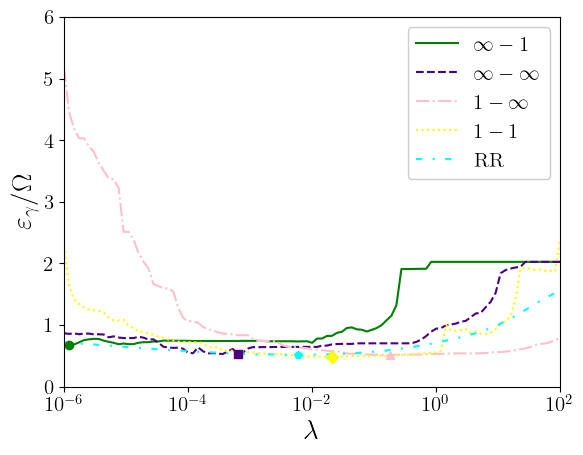

In [18]:
# Define colorblind-friendly colors for each line and marker
color_inf_1 = 'green'
color_inf_inf = 'indigo'
color_1_inf = 'pink'
color_1_1 = 'yellow'
color_RR = 'cyan'

# Modify line styles for better differentiation
line_style_inf_1 = '-'
line_style_inf_inf = '--'
line_style_1_inf = '-.'
line_style_1_1 = ':'
line_style_RR = (0, (3, 5, 1, 5))  # Custom dash pattern

# Modify marker styles for optimal lambda values
marker_inf_1 = 'o'
marker_inf_inf = 's'  # Square
marker_1_inf = '^'    # Triangle
marker_1_1 = 'D'      # Diamond
marker_RR = 'p'       # Pentagon

# Plotting the lines with colorblind-friendly colors, line styles, and markers
plt.semilogx(lambda_reg_vec, norm_diff_inf_1, label=r'$\infty-1$', color=color_inf_1, linestyle=line_style_inf_1)
plt.semilogx(lambda_reg_vec, norm_diff_inf_inf, label=r'$\infty-\infty$', color=color_inf_inf, linestyle=line_style_inf_inf)
plt.semilogx(lambda_reg_vec, norm_diff_1_inf, label=r'$1-\infty$', color=color_1_inf, linestyle=line_style_1_inf)
plt.semilogx(lambda_reg_vec, norm_diff_1_1, label=r'$1-1$', color=color_1_1, linestyle=line_style_1_1)
plt.semilogx(lambda_reg_vec, norm_diff_RR, label=r'$\rm RR$', color=color_RR, linestyle=line_style_RR)

# Adding markers for optimal lambda values with corresponding colors
plt.semilogx(optimal_lambda_inf_1, np.min(norm_diff_inf_1), marker=marker_inf_1, color=color_inf_1)
plt.semilogx(optimal_lambda_inf_inf, np.min(norm_diff_inf_inf), marker=marker_inf_inf, color=color_inf_inf)
plt.semilogx(optimal_lambda_1_inf, np.min(norm_diff_1_inf), marker=marker_1_inf, color=color_1_inf)
plt.semilogx(optimal_lambda_1_1, np.min(norm_diff_1_1), marker=marker_1_1, color=color_1_1)
plt.semilogx(optimal_lambda_RR, np.min(norm_diff_RR), marker=marker_RR, color=color_RR)

# Other plot settings (unchanged)
plt.legend(frameon=True, loc='upper right', fontsize=15, framealpha=1.0)
plt.xlim(10**(-6), 10**2)
plt.ylim(0, 6)
plt.xscale('log')
plt.xticks([10**-6, 10**-4, 10**-2, 1, 10**2], [r'$10^{-6}$', r'$10^{-4}$', r'$10^{-2}$', r'$10^{0}$', r'$10^{2}$'])
plt.xlabel(r'$\lambda$', fontsize=20)
plt.ylabel(r'$\varepsilon_{\gamma}/\Omega$', fontsize=20)
fig.set_size_inches(6.472, 4)
plt.show()

## 4.7 Compute the optimized DRTs and Impedances

In [19]:
# optimized DRTs
x_inf_1 = prob_inf_1(optimal_lambda_inf_1, A, L, b)
x_inf_inf = prob_inf_inf(optimal_lambda_inf_inf, A, L, b)
x_1_inf = prob_1_inf(optimal_lambda_1_inf, A, L, b)
x_1_1 = prob_1_1(optimal_lambda_1_1, A, L, b)
x_RR = prob_RR(optimal_lambda_RR, A, L2, b)

# recovered impedances
Z_inf_1_mat_FC = np.dot(A, x_inf_1)
Z_inf_1_mat_FC = Z_inf_1_mat_FC[:N_freqs] + 1j*Z_inf_1_mat_FC[N_freqs:]
Z_inf_inf_mat_FC = np.dot(A, x_inf_inf)
Z_inf_inf_mat_FC = Z_inf_inf_mat_FC[:N_freqs] + 1j*Z_inf_inf_mat_FC[N_freqs:]
Z_1_inf_mat_FC = np.dot(A, x_1_inf)
Z_1_inf_mat_FC = Z_1_inf_mat_FC[:N_freqs] + 1j*Z_1_inf_mat_FC[N_freqs:]
Z_1_1_mat_FC = np.dot(A, x_1_1)
Z_1_1_mat_FC = Z_1_1_mat_FC[:N_freqs] + 1j*Z_1_1_mat_FC[N_freqs:]
Z_RR_mat_FC = np.dot(A, x_RR)
Z_RR_mat_FC = Z_RR_mat_FC[:N_freqs] + 1j*Z_RR_mat_FC[N_freqs:]

     pcost       dcost       gap    pres   dres
 0: -1.5671e+03 -1.6493e+03  4e+02  9e+00  5e-02
 1: -1.5595e+03 -1.6085e+03  5e+01  2e-15  7e-17
 2: -1.5665e+03 -1.5725e+03  6e+00  8e-16  7e-17
 3: -1.5675e+03 -1.5683e+03  7e-01  8e-16  8e-17
 4: -1.5677e+03 -1.5677e+03  8e-02  8e-16  9e-17
 5: -1.5677e+03 -1.5677e+03  1e-02  6e-16  1e-16
 6: -1.5677e+03 -1.5677e+03  1e-03  4e-16  9e-17
Optimal solution found.


# 5. Comparison

## 5.1 Compute the DRT and Impedance Residuals

In [20]:
L1 = compute_DRT.compute_L1(log_tau_vec)
# DRT residuals
print('DRT error for the inf- and 1-norm', np.linalg.norm(x_inf_1[1:]-gamma_ECM) + np.linalg.norm(np.dot(L1, x_inf_1[1:]-gamma_ECM)))
print('DRT error for the inf-norm', np.linalg.norm(x_inf_inf[1:]-gamma_ECM) + np.linalg.norm(np.dot(L1, x_inf_inf[1:]-gamma_ECM)))
print('DRT error for the 1- and inf-norm', np.linalg.norm(x_1_inf[1:]-gamma_ECM) + np.linalg.norm(np.dot(L1, x_1_inf[1:]-gamma_ECM)))
print('DRT error for the 1-norm', np.linalg.norm(x_1_1[1:]-gamma_ECM) + np.linalg.norm(np.dot(L1, x_1_1[1:]-gamma_ECM)))
print('DRT error for the RR', np.linalg.norm(x_RR[1:]-gamma_ECM) + np.linalg.norm(np.dot(L1, x_RR[1:]-gamma_ECM)))
print('----------')

# impedance residuals
print('Impedance error for the inf- and 1-norm', np.linalg.norm(Z_inf_1_mat_FC-Z_ECM))
print('Impedance error for the inf-norm', np.linalg.norm(Z_inf_inf_mat_FC-Z_ECM))
print('Impedance error for the 1- and inf-norm', np.linalg.norm(Z_1_inf_mat_FC-Z_ECM))
print('Impedance error for the 1-norm', np.linalg.norm(Z_1_1_mat_FC-Z_ECM))
print('Impedance error for the RR', np.linalg.norm(Z_RR_mat_FC-Z_ECM))

DRT error for the inf- and 1-norm 1.9616616747343227
DRT error for the inf-norm 1.4868026283517768
DRT error for the 1- and inf-norm 1.4725079139477018
DRT error for the 1-norm 1.3538167627819961
DRT error for the RR 1.4332912680835947
----------
Impedance error for the inf- and 1-norm 0.38618613198055685
Impedance error for the inf-norm 0.3791573614345567
Impedance error for the 1- and inf-norm 0.2771308915102219
Impedance error for the 1-norm 0.2784543457664775
Impedance error for the RR 0.28352287902824774


## 5.2 Plots of the DRTs recovered with the 1-norm and RR (Figure S2 in the Supplementary Information (SI))

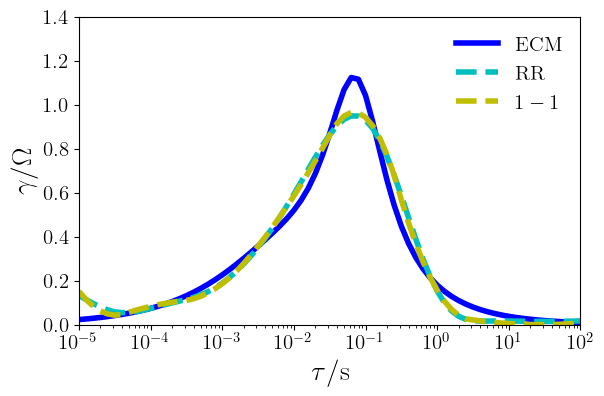

In [21]:
fig = plt.gcf()
plt.semilogx(tau_vec, gamma_ECM, linewidth=4, color='blue', label='ECM')
plt.semilogx(tau_vec, x_RR[1:], '--', linewidth=4, color='c', label='RR')
plt.semilogx(tau_vec, x_1_1[1:], '--', linewidth=4, color='y', label=r'$1-1$')#' \; \rm with \; \mathbf {\mathit{L}}_{3}$')
plt.xlabel(r'$\tau/\rm s$', fontsize = 20)
plt.ylabel(r'$\gamma/\Omega$', fontsize = 20)
plt.legend(frameon=False, fontsize=15, loc='upper right')
plt.xlim(np.min(tau_vec), np.max(tau_vec))
plt.ylim([0, 1.4])
plt.yticks(np.arange(0, 1.41, step=0.2))
fig.set_size_inches(6.472, 4)
plt.show()

## 5.3 Bode plots of the experimental, ECM-based impedances, and the impedances recovered with the 1-norm and RR

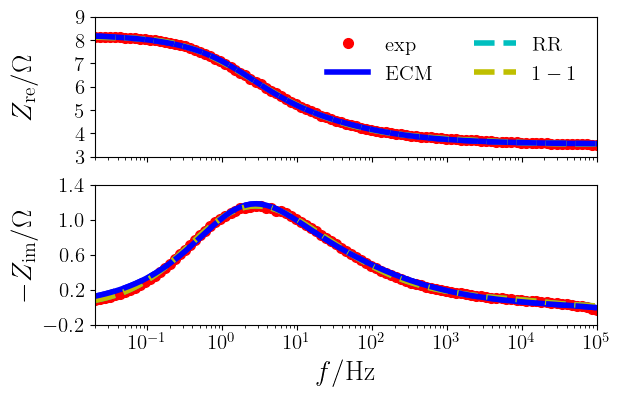

In [22]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.semilogx(freq_vec, Z_exp.real, 'o', markersize=7, color='red', label='exp')
ax1.semilogx(freq_vec, Z_ECM.real, linewidth=4, color='blue', label='ECM')
ax1.semilogx(freq_vec, np.real(Z_1_1_mat_FC), '--', linewidth=4, color='c', label='RR')
ax1.semilogx(freq_vec, np.real(Z_1_1_mat_FC), '--', linewidth=4, color='y', label=r'$1-1$')#' \; \rm with \; \mathbf {\mathit{L}}_{3}$')
#ax1.fill_between(freq_vec, Z_L2_re_mean_PWC-3*Z_L2_re_std_PWC, Z_L2_re_mean_PWC+3*Z_L2_re_std_PWC, 
                 #color='y', alpha=0.25)
ax1.semilogx(freq_vec, Z_ECM.real, '--', linewidth=4, color='blue')
ax1.set_ylabel(r'$Z_{\rm re}/\Omega$', fontsize = 20)
ax1.axis([np.min(freq_vec), np.max(freq_vec), 3, 9])
ax1.set_yticks(np.arange(3, 9.1, step=1)) 
ax1.legend(frameon=False, fontsize = 15, loc='upper right', ncol=2)

ax2.semilogx(freq_vec, -Z_exp.imag, 'o', markersize=7, color='red', label='exp')
ax2.semilogx(freq_vec, -Z_ECM.imag, linewidth=4, color='blue', label='ECM')
ax2.semilogx(freq_vec, -np.imag(Z_1_1_mat_FC), '--', linewidth=4, color='c', label='RR')
ax2.semilogx(freq_vec, -np.imag(Z_1_1_mat_FC), '--', linewidth=4, color='y', label=r'$1-1$')#' \; \rm with \; \mathbf {\mathit{L}}_{3}$')
#ax2.fill_between(freq_vec, -Z_L2_im_mean_PWC-3*Z_L2_im_std_PWC, -Z_L2_im_mean_PWC+3*Z_L2_im_std_PWC, 
                 #color='y', alpha=0.25)
ax2.semilogx(freq_vec, -Z_ECM.imag, '--', linewidth=4, color='blue')
ax2.set_ylabel(r'$-Z_{\rm im}/\Omega$', fontsize = 20)
ax2.axis([np.min(freq_vec), np.max(freq_vec), -0.2, 1.3])
ax2.set_yticks(np.arange(-0.2, 1.41, 0.4))
#ax2.legend(frameon=False, fontsize = 15, loc='upper right', ncol=2)

plt.xlabel(r'$f/{\rm Hz}$', fontsize = 20)
fig.align_ylabels()
fig.set_size_inches(6.472, 4)
plt.show()